In [2]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [3]:
# ============================================================
# 2. LOAD DATASETS
# ============================================================

DATA_PATH = "."

train_path = os.path.join(DATA_PATH, "orders_train.csv")
test_path = os.path.join(DATA_PATH, "orders_test.csv")
sample_path = os.path.join(DATA_PATH, "sample_submission.csv")
metadata_path = os.path.join(DATA_PATH, "hub_metadata.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv(sample_path)
metadata = pd.read_csv(metadata_path)

print("Files loaded successfully.")

Files loaded successfully.


In [4]:
# ============================================================
# 3. DATASET SHAPES
# ============================================================

print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE:", test.shape)
print("SAMPLE SUBMISSION SHAPE:", sample_submission.shape)
print("METADATA SHAPE:", metadata.shape)

TRAIN SHAPE: (970379, 9)
TEST SHAPE: (46830, 8)
SAMPLE SUBMISSION SHAPE: (46830, 2)
METADATA SHAPE: (1115, 10)


In [5]:
# ============================================================
# 4. FIRST 5 ROWS
# ============================================================

print("========== TRAIN ==========")
display(train.head())

print("========== TEST ==========")
display(test.head())

print("========== METADATA ==========")
display(metadata.head())

print("========== SAMPLE SUBMISSION ==========")
display(sample_submission.head())

========== TRAIN ==========


,HubID,Weekday,Date,OrderVolume,AppSessions,IsOpen,PromoActive,RegionalHoliday,SchoolClosureFlag
0,1,2,2013-01-01,0,0,0,0,1,1
1,2,2,2013-01-01,0,0,0,0,1,1
2,3,2,2013-01-01,0,0,0,0,1,1
3,4,2,2013-01-01,0,0,0,0,1,1
4,5,2,2013-01-01,0,0,0,0,1,1


========== TEST ==========


,Id,HubID,Weekday,Date,IsOpen,PromoActive,RegionalHoliday,SchoolClosureFlag
0,1,1,6,2015-06-20,1,0,0,0
1,2,2,6,2015-06-20,1,0,0,0
2,3,3,6,2015-06-20,1,0,0,0
3,4,4,6,2015-06-20,1,0,0,0
4,5,5,6,2015-06-20,1,0,0,0


========== METADATA ==========


,HubID,HubFormat,AssortmentTier,CompetitorDistance,CompetitorOpenSinceMonth,CompetitorOpenSinceYear,LoyaltyProgram,LoyaltyProgramSinceWeek,LoyaltyProgramSinceYear,LoyaltyProgramInterval
0,1,3,1,1270.000,9.000,2008.000,0,NaN,NaN,NaN
1,2,1,1,570.000,11.000,2007.000,1,13.000,2010.000,"Jan,Apr,Jul,Oct"
2,3,1,1,14130.000,12.000,2006.000,1,14.000,2011.000,"Jan,Apr,Jul,Oct"
3,4,3,3,620.000,9.000,2009.000,0,NaN,NaN,NaN
4,5,1,1,29910.000,4.000,2015.000,0,NaN,NaN,NaN


========== SAMPLE SUBMISSION ==========


,Id,OrderVolume
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [6]:
# ============================================================
# 5. COLUMN INFORMATION
# ============================================================

print("========== TRAIN INFO ==========")
train.info()

print("\n========== TEST INFO ==========")
test.info()

print("\n========== METADATA INFO ==========")
metadata.info()

========== TRAIN INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 970379 entries, 0 to 970378
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   HubID              970379 non-null  int64
 1   Weekday            970379 non-null  int64
 2   Date               970379 non-null  str  
 3   OrderVolume        970379 non-null  int64
 4   AppSessions        970379 non-null  int64
 5   IsOpen             970379 non-null  int64
 6   PromoActive        970379 non-null  int64
 7   RegionalHoliday    970379 non-null  int64
 8   SchoolClosureFlag  970379 non-null  int64
dtypes: int64(8), str(1)
memory usage: 66.6 MB

========== TEST INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 46830 entries, 0 to 46829
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 46830 non-null  int64
 1   HubID              46830 non-nu

In [7]:
# ============================================================
# 6. COLUMN NAMES
# ============================================================

print("TRAIN COLUMNS:")
print(train.columns.tolist())

print("\nTEST COLUMNS:")
print(test.columns.tolist())

print("\nMETADATA COLUMNS:")
print(metadata.columns.tolist())

TRAIN COLUMNS:
['HubID', 'Weekday', 'Date', 'OrderVolume', 'AppSessions', 'IsOpen', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag']

TEST COLUMNS:
['Id', 'HubID', 'Weekday', 'Date', 'IsOpen', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag']

METADATA COLUMNS:
['HubID', 'HubFormat', 'AssortmentTier', 'CompetitorDistance', 'CompetitorOpenSinceMonth', 'CompetitorOpenSinceYear', 'LoyaltyProgram', 'LoyaltyProgramSinceWeek', 'LoyaltyProgramSinceYear', 'LoyaltyProgramInterval']


In [8]:
# ============================================================
# 7. TRAIN VS TEST COLUMN COMPARISON
# ============================================================

train_columns = set(train.columns)
test_columns = set(test.columns)

print("Columns only in TRAIN:")
print(sorted(train_columns - test_columns))

print("\nColumns only in TEST:")
print(sorted(test_columns - train_columns))

print("\nCommon columns:")
print(sorted(train_columns & test_columns))

Columns only in TRAIN:
['AppSessions', 'OrderVolume']

Columns only in TEST:
['Id']

Common columns:
['Date', 'HubID', 'IsOpen', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag', 'Weekday']


In [9]:
# ============================================================
# 8. MISSING VALUES
# ============================================================

def missing_summary(df, name):
    result = pd.DataFrame({
        "MissingCount": df.isnull().sum(),
        "MissingPercentage": df.isnull().mean() * 100,
        "DataType": df.dtypes.astype(str)
    })
    
    result = result.sort_values(
        "MissingPercentage",
        ascending=False
    )
    
    print(f"\n========== {name} ==========")
    display(result)

missing_summary(train, "TRAIN")
missing_summary(test, "TEST")
missing_summary(metadata, "METADATA")


========== TRAIN ==========


,MissingCount,MissingPercentage,DataType
HubID,0,0.000,int64
Weekday,0,0.000,int64
Date,0,0.000,str
OrderVolume,0,0.000,int64
AppSessions,0,0.000,int64
IsOpen,0,0.000,int64
PromoActive,0,0.000,int64
RegionalHoliday,0,0.000,int64
SchoolClosureFlag,0,0.000,int64



========== TEST ==========


,MissingCount,MissingPercentage,DataType
Id,0,0.000,int64
HubID,0,0.000,int64
Weekday,0,0.000,int64
Date,0,0.000,str
IsOpen,0,0.000,int64
PromoActive,0,0.000,int64
RegionalHoliday,0,0.000,int64
SchoolClosureFlag,0,0.000,int64



========== METADATA ==========


,MissingCount,MissingPercentage,DataType
LoyaltyProgramInterval,544,48.789,str
LoyaltyProgramSinceYear,544,48.789,float64
LoyaltyProgramSinceWeek,544,48.789,float64
CompetitorOpenSinceYear,354,31.749,float64
CompetitorOpenSinceMonth,354,31.749,float64
CompetitorDistance,3,0.269,float64
HubFormat,0,0.000,int64
HubID,0,0.000,int64
AssortmentTier,0,0.000,int64
LoyaltyProgram,0,0.000,int64


In [10]:
# ============================================================
# 9. DUPLICATES
# ============================================================

print("Duplicate rows in TRAIN:", train.duplicated().sum())
print("Duplicate rows in TEST:", test.duplicated().sum())
print("Duplicate rows in METADATA:", metadata.duplicated().sum())

Duplicate rows in TRAIN: 0
Duplicate rows in TEST: 0
Duplicate rows in METADATA: 0


In [11]:
# ============================================================
# 10. DUPLICATE HUB-DATE RECORDS
# ============================================================

if "Date" in train.columns and "HubID" in train.columns:
    print(
        "Duplicate HubID-Date combinations in TRAIN:",
        train.duplicated(["HubID", "Date"]).sum()
    )

if "Date" in test.columns and "HubID" in test.columns:
    print(
        "Duplicate HubID-Date combinations in TEST:",
        test.duplicated(["HubID", "Date"]).sum()
    )

Duplicate HubID-Date combinations in TRAIN: 0
Duplicate HubID-Date combinations in TEST: 0


In [12]:
# ============================================================
# 11. DATE CONVERSION
# ============================================================

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

print("Train date range:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTest date range:")
print(test["Date"].min(), "to", test["Date"].max())

Train date range:
2013-01-01 00:00:00 to 2015-06-19 00:00:00

Test date range:
2015-06-20 00:00:00 to 2015-07-31 00:00:00


In [13]:
# ============================================================
# 12. HUB COUNTS
# ============================================================

print("Unique hubs in TRAIN:", train["HubID"].nunique())
print("Unique hubs in TEST:", test["HubID"].nunique())
print("Unique hubs in METADATA:", metadata["HubID"].nunique())

Unique hubs in TRAIN: 1115
Unique hubs in TEST: 1115
Unique hubs in METADATA: 1115


In [14]:
train_hubs = set(train["HubID"])
test_hubs = set(test["HubID"])
metadata_hubs = set(metadata["HubID"])

print("\nTest hubs missing from metadata:")
print(len(test_hubs - metadata_hubs))

print("\nTrain hubs missing from metadata:")
print(len(train_hubs - metadata_hubs))


Test hubs missing from metadata:
0

Train hubs missing from metadata:
0


In [15]:
# ============================================================
# 13. HUB OVERLAP
# ============================================================

common_hubs = train_hubs & test_hubs

print("Hubs appearing in both TRAIN and TEST:", len(common_hubs))

print("Hubs only in TRAIN:", len(train_hubs - test_hubs))

print("Hubs only in TEST:", len(test_hubs - train_hubs))

Hubs appearing in both TRAIN and TEST: 1115
Hubs only in TRAIN: 0
Hubs only in TEST: 0


In [16]:
# ============================================================
# 14. TARGET ANALYSIS
# ============================================================

print(train["OrderVolume"].describe())
print("Minimum:", train["OrderVolume"].min())
print("Maximum:", train["OrderVolume"].max())
print("Mean:", train["OrderVolume"].mean())
print("Median:", train["OrderVolume"].median())

count   970379.000
mean      5762.766
std       3855.457
min          0.000
25%       3708.000
50%       5736.000
75%       7850.000
max      38722.000
Name: OrderVolume, dtype: float64
Minimum: 0
Maximum: 38722
Mean: 5762.766017195343
Median: 5736.0


In [17]:
# ============================================================
# 15. ZERO ORDER VOLUME
# ============================================================

zero_orders = (train["OrderVolume"] == 0).sum()
total_orders = len(train)

print("Zero OrderVolume rows:", zero_orders)
print(
    "Percentage of zero OrderVolume rows:",
    zero_orders / total_orders * 100
)

Zero OrderVolume rows: 166323
Percentage of zero OrderVolume rows: 17.140004060269234


In [18]:
zero_open_status = pd.crosstab(
    train["IsOpen"],
    train["OrderVolume"] == 0
)

display(zero_open_status)

OrderVolume,False,True
IsOpen,,
0,0,166269
1,804056,54


In [19]:
# ============================================================
# 16. ORDER VOLUME BY OPERATING STATUS
# ============================================================

display(
    train.groupby("IsOpen")["OrderVolume"]
    .agg(["count", "mean", "median", "min", "max"])
)

,count,mean,median,min,max
IsOpen,,,,,
0,166269,0.000,0.000,0,0
1,804110,6954.356,6368.000,0,38722


In [20]:
# ============================================================
# 17. HUB-LEVEL DEMAND STATISTICS
# ============================================================

hub_stats = (
    train.groupby("HubID")["OrderVolume"]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .sort_values("mean", ascending=False)
)

display(hub_stats.head(20))
display(hub_stats.describe())

,observations,mean,median,std,min,max
HubID,,,,,,
262,900,20695.976,19407.000,4675.944,13210,38722
817,900,18121.117,20914.000,9226.621,0,38025
562,900,18001.093,18046.000,2939.181,8498,28680
1114,900,17090.772,19505.000,8318.059,0,35697
251,900,15808.144,17656.500,7958.175,0,35350
513,900,15153.661,17062.000,7463.976,0,31094
842,716,15115.036,17203.000,7907.477,0,35154
733,900,14948.253,14810.500,1855.831,6838,22137
788,900,14941.241,16555.500,7327.623,0,32170


,observations,mean,median,std,min,max
count,1115.000,1115.000,1115.000,1115.000,1115.000,1115.000
mean,870.295,5751.384,6204.781,3102.379,50.912,15323.440
std,67.729,2044.621,2218.635,996.273,610.015,5285.295
min,716.000,2243.858,2017.500,1278.167,0.000,5759.000
25%,900.000,4399.141,4703.750,2420.303,0.000,11681.000
50%,900.000,5446.432,5843.500,2972.128,0.000,14524.000
75%,900.000,6613.103,7144.000,3572.164,0.000,17925.000
max,900.000,20695.976,20914.000,9226.621,13210.000,38722.000


In [21]:
# ============================================================
# 18. CATEGORICAL VALUE COUNTS
# ============================================================

categorical_columns = [
    "IsOpen",
    "RegionalHoliday",
    "SchoolClosureFlag",
    "HubFormat",
    "AssortmentTier",
    "PromoActive",
    "LoyaltyProgram"
]

for col in categorical_columns:
    if col in train.columns:
        print(f"\n========== {col} ==========")
        print(train[col].value_counts(dropna=False))


========== IsOpen ==========
IsOpen
1    804110
0    166269
Name: count, dtype: int64

========== RegionalHoliday ==========
RegionalHoliday
0    939329
1     20260
2      6690
3      4100
Name: count, dtype: int64

========== SchoolClosureFlag ==========
SchoolClosureFlag
0    802007
1    168372
Name: count, dtype: int64

========== PromoActive ==========
PromoActive
0    599024
1    371355
Name: count, dtype: int64


In [22]:
# ============================================================
# 19. METADATA HUB UNIQUENESS
# ============================================================

metadata_duplicates = metadata["HubID"].duplicated().sum()

print("Duplicate HubIDs in metadata:", metadata_duplicates)

Duplicate HubIDs in metadata: 0


In [23]:
# ============================================================
# 21. TEMPORAL ORDER CHECK
# ============================================================

latest_train_date = train["Date"].max()
earliest_test_date = test["Date"].min()

print("Latest training date:", latest_train_date)
print("Earliest test date:", earliest_test_date)

if earliest_test_date > latest_train_date:
    print("\nTest period is entirely AFTER training period.")
else:
    print("\nWARNING: Train and test periods overlap!")

Latest training date: 2015-06-19 00:00:00
Earliest test date: 2015-06-20 00:00:00

Test period is entirely AFTER training period.


In [24]:
# ============================================================
# 22. OBSERVATIONS PER HUB
# ============================================================

train_obs_per_hub = train.groupby("HubID").size()

print("Minimum observations per hub:", train_obs_per_hub.min())
print("Maximum observations per hub:", train_obs_per_hub.max())
print("Median observations per hub:", train_obs_per_hub.median())

display(train_obs_per_hub.describe())

Minimum observations per hub: 716
Maximum observations per hub: 900
Median observations per hub: 900.0


count   1115.000
mean     870.295
std       67.729
min      716.000
25%      900.000
50%      900.000
75%      900.000
max      900.000
dtype: float64

In [25]:
# ============================================================
# 23. DAILY DATA COVERAGE
# ============================================================

daily_stats = (
    train.groupby("Date")
    .agg(
        hubs=("HubID", "nunique"),
        rows=("HubID", "size"),
        total_orders=("OrderVolume", "sum"),
        mean_orders=("OrderVolume", "mean")
    )
)

display(daily_stats.head())
display(daily_stats.tail())

,hubs,rows,total_orders,mean_orders
Date,,,,
2013-01-01,1114,1114,97235,87.285
2013-01-02,1115,1115,6949829,6233.030
2013-01-03,1115,1115,6347820,5693.112
2013-01-04,1115,1115,6638954,5954.219
2013-01-05,1115,1115,5951593,5337.752


,hubs,rows,total_orders,mean_orders
Date,,,,
2015-06-15,1115,1115,11570100,10376.771
2015-06-16,1115,1115,9636747,8642.822
2015-06-17,1115,1115,8618478,7729.577
2015-06-18,1115,1115,8191358,7346.509
2015-06-19,1115,1115,8458252,7585.876


In [26]:
# ============================================================
# 24. PANEL COMPLETENESS
# ============================================================

expected_rows = (
    train["HubID"].nunique()
    * train["Date"].nunique()
)

actual_rows = len(train)

print("Expected rows if every hub had every date:", expected_rows)
print("Actual rows:", actual_rows)

print(
    "Coverage:",
    actual_rows / expected_rows * 100,
    "%"
)

Expected rows if every hub had every date: 1003500
Actual rows: 970379
Coverage: 96.699451918286 %


In [27]:
# ============================================================
# 25. FINAL DATASET SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Dataset": ["Train", "Test", "Metadata", "Sample Submission"],
    "Rows": [
        len(train),
        len(test),
        len(metadata),
        len(sample_submission)
    ],
    "Columns": [
        train.shape[1],
        test.shape[1],
        metadata.shape[1],
        sample_submission.shape[1]
    ]
})

display(summary)

,Dataset,Rows,Columns
0,Train,970379,9
1,Test,46830,8
2,Metadata,1115,10
3,Sample Submission,46830,2


In [28]:
train.groupby("Weekday")["OrderVolume"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Weekday,,,,
1,138040,7789.811,7299.000,4037.627
2,138974,6990.017,6455.000,3136.579
3,138975,6543.865,6124.000,2953.018
4,139155,6221.276,6004.000,3232.839
5,139155,6709.537,6430.000,3116.673
6,138040,5857.736,5418.000,2884.628
7,138040,202.176,0.000,1604.377


In [29]:
train[train["IsOpen"] == 1].groupby("Weekday")["OrderVolume"].agg(
    ["count", "mean", "median", "std"]
)

,count,mean,median,std
Weekday,,,,
1,130878,8216.090,7538.000,3700.294
2,137279,7076.324,6495.000,3057.591
3,135254,6723.895,6204.000,2783.831
4,127964,6765.353,6242.000,2772.068
5,131959,7075.422,6584.000,2766.686
6,137376,5886.049,5434.000,2862.629
7,3400,8208.334,6840.000,6228.870


In [30]:
train.groupby(
    ["IsOpen", "Weekday"]
)["OrderVolume"].mean()

IsOpen  Weekday
0       1            0.000
        2            0.000
        3            0.000
        4            0.000
        5            0.000
        6            0.000
        7            0.000
1       1         8216.090
        2         7076.324
        3         6723.895
        4         6765.353
        5         7075.422
        6         5886.049
        7         8208.334
Name: OrderVolume, dtype: float64

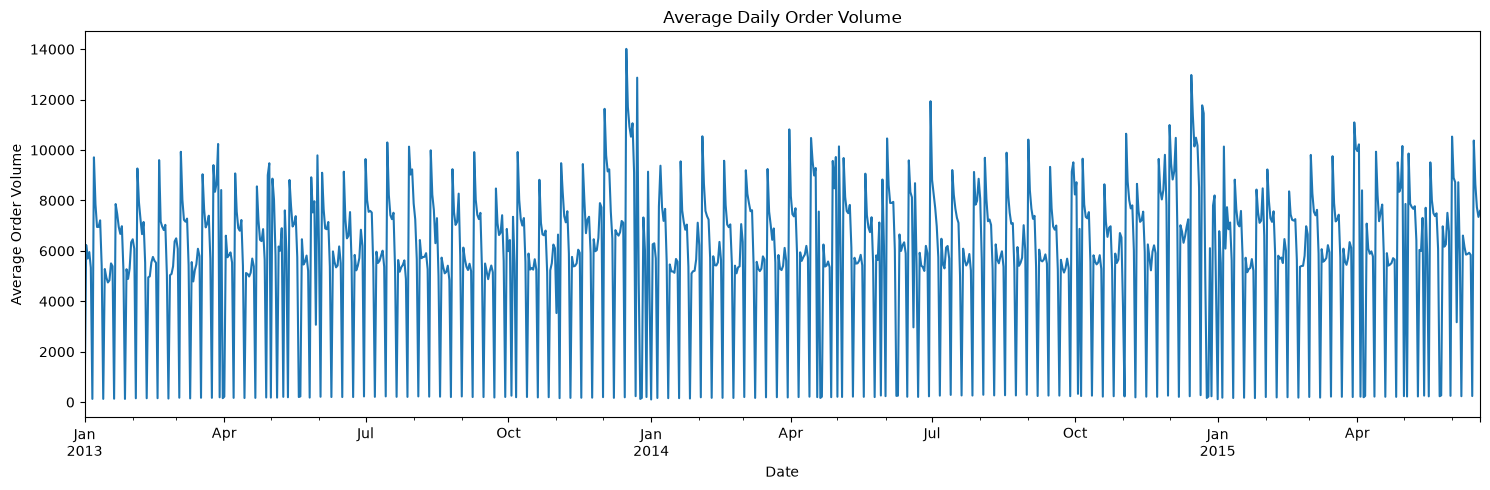

In [31]:
# ============================================================
# 26. DAILY AVERAGE ORDER VOLUME
# ============================================================

import matplotlib.pyplot as plt

train.groupby("Date")["OrderVolume"].mean().sort_index().plot(
    figsize=(15, 5),
    title="Average Daily Order Volume"
)
plt.xlabel("Date")
plt.ylabel("Average Order Volume")
plt.tight_layout()
plt.show()

In [32]:
hub_weekday = (
    train[train["IsOpen"] == 1]
    .groupby(["HubID", "Weekday"])["OrderVolume"]
    .agg(["mean", "median", "std", "count"])
)

display(hub_weekday.head(20))

mean    median      std  count
HubID Weekday                                    
1     1        5195.303  5331.500 1252.765    122
      2        4696.219  4640.500 1035.261    128
      3        4571.230  4549.500  927.765    126
      4        4462.441  4380.000  929.365    118
      5        4748.821  4651.000  916.333    123
      6        4977.695  4881.500  856.855    128
2     1        6080.148  6530.500 1843.833    122
      2        5356.047  5452.000 1473.491    128
      3        5836.508  5920.500 1193.649    126
      4        4973.876  5009.000  998.653    121
      5        4672.894  4701.000  829.871    123
      6        2863.211  2735.000  513.879    128
3     1        8369.902  9000.000 2701.599    122
      2        7618.141  7928.000 2173.827    128
      3        7140.119  7478.000 1741.485    126
      4        6929.695  6940.000 1429.341    118
      5        7212.869  7149.000 1494.146    122
      6        4476.898  4221.000 1047.728    127
4     1       10840.820 11106.500 2334.581    122
      2        9377.289  9599.500 1962.257    128

In [33]:
hub_stats = (
    train[train["IsOpen"] == 1]
    .groupby("HubID")["OrderVolume"]
    .agg(["mean", "median", "std", "min", "max"])
)

display(hub_stats.describe())

,mean,median,std,min,max
count,1115.000,1115.000,1115.000,1115.000,1115.000
mean,6932.119,6678.313,1846.959,2800.753,15323.440
std,2385.062,2316.663,623.424,1507.713,5285.295
min,2707.067,2308.000,579.353,0.000,5759.000
25%,5318.297,5112.750,1410.648,1850.000,11681.000
50%,6598.776,6332.000,1765.549,2645.000,14524.000
75%,7968.187,7632.500,2154.902,3553.500,17925.000
max,21803.483,21888.000,4905.662,13210.000,38722.000


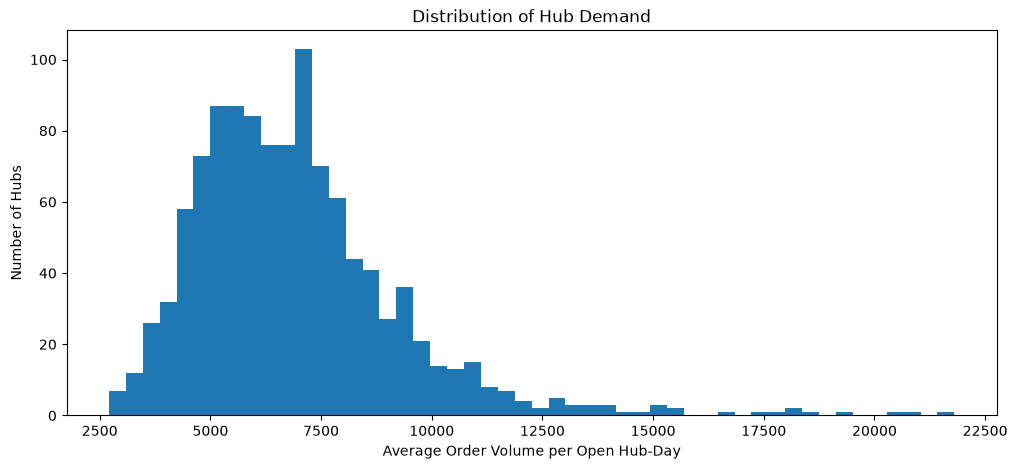

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.hist(hub_stats["mean"], bins=50)
plt.xlabel("Average Order Volume per Open Hub-Day")
plt.ylabel("Number of Hubs")
plt.title("Distribution of Hub Demand")
plt.show()

In [35]:


import pandas as pd
import numpy as np

# Make copies so we don't accidentally modify the original data
train_model = train.copy()
test_model = test.copy()
metadata_model = metadata.copy()

# Convert dates
train_model["Date"] = pd.to_datetime(train_model["Date"])
test_model["Date"] = pd.to_datetime(test_model["Date"])

# Sort chronologically within each hub
train_model = train_model.sort_values(
    ["HubID", "Date"]
).reset_index(drop=True)

test_model = test_model.sort_values(
    ["HubID", "Date"]
).reset_index(drop=True)

# Merge static hub information
train_model = train_model.merge(
    metadata_model,
    on="HubID",
    how="left",
    validate="many_to_one"
)

test_model = test_model.merge(
    metadata_model,
    on="HubID",
    how="left",
    validate="many_to_one"
)

print("Train shape after metadata merge:", train_model.shape)
print("Test shape after metadata merge:", test_model.shape)

print("\nMissing metadata after merge:")
print(train_model[metadata_model.columns.difference(["HubID"])].isnull().sum())

Train shape after metadata merge: (970379, 18)
Test shape after metadata merge: (46830, 17)

Missing metadata after merge:
AssortmentTier                   0
CompetitorDistance            2516
CompetitorOpenSinceMonth    308480
CompetitorOpenSinceYear     308480
HubFormat                        0
LoyaltyProgram                   0
LoyaltyProgramInterval      485183
LoyaltyProgramSinceWeek     485183
LoyaltyProgramSinceYear     485183
dtype: int64


In [36]:
# ============================================================
# TIME FEATURES
# ============================================================

def create_time_features(df):
    df = df.copy()
    
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day_of_month"] = df["Date"].dt.day
    df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
    df["day_of_year"] = df["Date"].dt.dayofyear
    
    df["is_weekend"] = (df["Weekday"] >= 6).astype(int)
    
    # Cyclic weekly representation
    df["weekday_sin"] = np.sin(
        2 * np.pi * df["Weekday"] / 7
    )
    
    df["weekday_cos"] = np.cos(
        2 * np.pi * df["Weekday"] / 7
    )
    
    # Cyclic yearly representation
    df["dayofyear_sin"] = np.sin(
        2 * np.pi * df["day_of_year"] / 365.25
    )
    
    df["dayofyear_cos"] = np.cos(
        2 * np.pi * df["day_of_year"] / 365.25
    )
    
    return df


train_model = create_time_features(train_model)
test_model = create_time_features(test_model)

In [37]:
# ============================================================
# LAG FEATURES
# ============================================================

LAG_DAYS = [
    1,
    2,
    3,
    7,
    14,
    21,
    28,
    35,
    42
]

for lag in LAG_DAYS:
    train_model[f"lag_{lag}"] = (
        train_model
        .groupby("HubID")["OrderVolume"]
        .shift(lag)
    )

In [38]:
# ============================================================
# SAME-WEEKDAY LAG FEATURES
# ============================================================

train_model["same_week_mean_2"] = train_model[
    ["lag_7", "lag_14"]
].mean(axis=1)

train_model["same_week_mean_4"] = train_model[
    ["lag_7", "lag_14", "lag_21", "lag_28"]
].mean(axis=1)

train_model["same_week_median_4"] = train_model[
    ["lag_7", "lag_14", "lag_21", "lag_28"]
].median(axis=1)

train_model["same_week_std_4"] = train_model[
    ["lag_7", "lag_14", "lag_21", "lag_28"]
].std(axis=1)

In [39]:
# ============================================================
# ROLLING FEATURES
# ============================================================

grouped_orders = train_model.groupby("HubID")["OrderVolume"]

shifted_orders = grouped_orders.shift(1)

train_model["rolling_mean_3"] = (
    shifted_orders
    .groupby(train_model["HubID"])
    .rolling(3)
    .mean()
    .reset_index(level=0, drop=True)
)

train_model["rolling_mean_7"] = (
    shifted_orders
    .groupby(train_model["HubID"])
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

train_model["rolling_mean_14"] = (
    shifted_orders
    .groupby(train_model["HubID"])
    .rolling(14)
    .mean()
    .reset_index(level=0, drop=True)
)

train_model["rolling_std_7"] = (
    shifted_orders
    .groupby(train_model["HubID"])
    .rolling(7)
    .std()
    .reset_index(level=0, drop=True)
)

train_model["rolling_std_14"] = (
    shifted_orders
    .groupby(train_model["HubID"])
    .rolling(14)
    .std()
    .reset_index(level=0, drop=True)
)

In [40]:
# ============================================================
# DEMAND MOMENTUM
# ============================================================

train_model["lag7_vs_lag14"] = (
    train_model["lag_7"] /
    (train_model["lag_14"] + 1)
)

train_model["lag7_vs_lag28"] = (
    train_model["lag_7"] /
    (train_model["lag_28"] + 1)
)

train_model["recent_vs_same_week"] = (
    train_model["rolling_mean_7"] /
    (train_model["same_week_mean_4"] + 1)
)

In [41]:
# ============================================================
# OPERATIONAL FEATURES
# ============================================================

train_model["promo_open"] = (
    train_model["PromoActive"] *
    train_model["IsOpen"]
)

train_model["holiday_open"] = (
    train_model["RegionalHoliday"] *
    train_model["IsOpen"]
)

In [42]:
# ============================================================
# TIME-BASED VALIDATION
# ============================================================

validation_start = (
    train_model["Date"].max() -
    pd.Timedelta(days=41)
)

train_cutoff = validation_start - pd.Timedelta(days=1)

print("Training data ends:", train_model["Date"].max())
print("Validation starts:", validation_start)
print("Validation ends:", train_model["Date"].max())

train_part = train_model[
    train_model["Date"] < validation_start
].copy()

valid_part = train_model[
    train_model["Date"] >= validation_start
].copy()

print("\nTraining rows:", len(train_part))
print("Validation rows:", len(valid_part))

print(
    "\nValidation date range:",
    valid_part["Date"].min(),
    "→",
    valid_part["Date"].max()
)

Training data ends: 2015-06-19 00:00:00
Validation starts: 2015-05-09 00:00:00
Validation ends: 2015-06-19 00:00:00

Training rows: 923549
Validation rows: 46830

Validation date range: 2015-05-09 00:00:00 → 2015-06-19 00:00:00


In [43]:
# ============================================================
# MODEL FEATURES
# ============================================================

FEATURES = [
    # Historical demand
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "lag_35",
    "lag_42",
    
    # Same-weekday statistics
    "same_week_mean_2",
    "same_week_mean_4",
    "same_week_median_4",
    "same_week_std_4",
    
    # Calendar
    "Weekday",
    "month",
    "day_of_month",
    "week_of_year",
    "is_weekend",
    "weekday_sin",
    "weekday_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    
    # Operational
    "IsOpen",
    "PromoActive",
    "RegionalHoliday",
    "SchoolClosureFlag",
    "promo_open",
    "holiday_open",
    
    # Hub metadata
    "HubFormat",
    "AssortmentTier",
    "CompetitorDistance",
    "CompetitorOpenSinceMonth",
    "CompetitorOpenSinceYear",
    "LoyaltyProgram",
    "LoyaltyProgramSinceWeek",
    "LoyaltyProgramSinceYear"
]

# Keep only features that actually exist
FEATURES = [col for col in FEATURES if col in train_model.columns]

print("Number of features:", len(FEATURES))
print(FEATURES)

Number of features: 36
['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35', 'lag_42', 'same_week_mean_2', 'same_week_mean_4', 'same_week_median_4', 'same_week_std_4', 'Weekday', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'weekday_sin', 'weekday_cos', 'dayofyear_sin', 'dayofyear_cos', 'IsOpen', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag', 'promo_open', 'holiday_open', 'HubFormat', 'AssortmentTier', 'CompetitorDistance', 'CompetitorOpenSinceMonth', 'CompetitorOpenSinceYear', 'LoyaltyProgram', 'LoyaltyProgramSinceWeek', 'LoyaltyProgramSinceYear']


In [44]:
# ============================================================
# REMOVE INCOMPLETE LAG ROWS
# ============================================================

required_lags = [
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "lag_35",
    "lag_42"
]

train_part_model = train_part.dropna(
    subset=required_lags
).copy()

valid_part_model = valid_part.dropna(
    subset=required_lags
).copy()

print("Training rows after lag filtering:", len(train_part_model))
print("Validation rows after lag filtering:", len(valid_part_model))

Training rows after lag filtering: 876719
Validation rows after lag filtering: 46830


In [45]:
y_train = np.log1p(train_part_model["OrderVolume"])

In [46]:
# ============================================================
# LIGHTGBM MODEL
# ============================================================

from lightgbm import LGBMRegressor

X_train = train_part_model[FEATURES]
X_valid = valid_part_model[FEATURES]

y_train = np.log1p(
    train_part_model["OrderVolume"]
)

y_valid_actual = valid_part_model["OrderVolume"]

model = LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

print("Model trained.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084276 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4288
[LightGBM] [Info] Number of data points in the train set: 876719, number of used features: 36
[LightGBM] [Info] Start training from score 7.270687
Model trained.


In [47]:
# ============================================================
# VALIDATION PREDICTIONS
# ============================================================

pred_log = model.predict(X_valid)

pred = np.expm1(pred_log)

# Never allow negative order predictions
pred = np.clip(pred, 0, None)

# Closed hubs must be zero
pred[
    valid_part_model["IsOpen"].values == 0
] = 0

In [48]:
# ============================================================
# RMSLE
# ============================================================

rmsle = np.sqrt(
    np.mean(
        (
            np.log1p(pred) -
            np.log1p(y_valid_actual.values)
        ) ** 2
    )
)

print(f"Validation RMSLE: {rmsle:.6f}")

Validation RMSLE: 0.129253


In [49]:
# ============================================================
# LAG-7 BASELINE
# ============================================================

baseline_pred = valid_part_model["lag_7"].values.copy()

baseline_pred[
    valid_part_model["IsOpen"].values == 0
] = 0

baseline_rmsle = np.sqrt(
    np.mean(
        (
            np.log1p(baseline_pred) -
            np.log1p(y_valid_actual.values)
        ) ** 2
    )
)

print(f"Lag-7 Baseline RMSLE: {baseline_rmsle:.6f}")
print(f"LightGBM RMSLE:       {rmsle:.6f}")

Lag-7 Baseline RMSLE: 2.221969
LightGBM RMSLE:       0.129253


In [50]:
# ============================================================
# STEP 17 — FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(importance_df)

,Feature,Importance
0,lag_1,8318
20,dayofyear_sin,7407
21,dayofyear_cos,7334
15,day_of_month,7183
1,lag_2,5803
12,same_week_std_4,5722
30,CompetitorDistance,5597
3,lag_7,5474
7,lag_35,5025
2,lag_3,4939


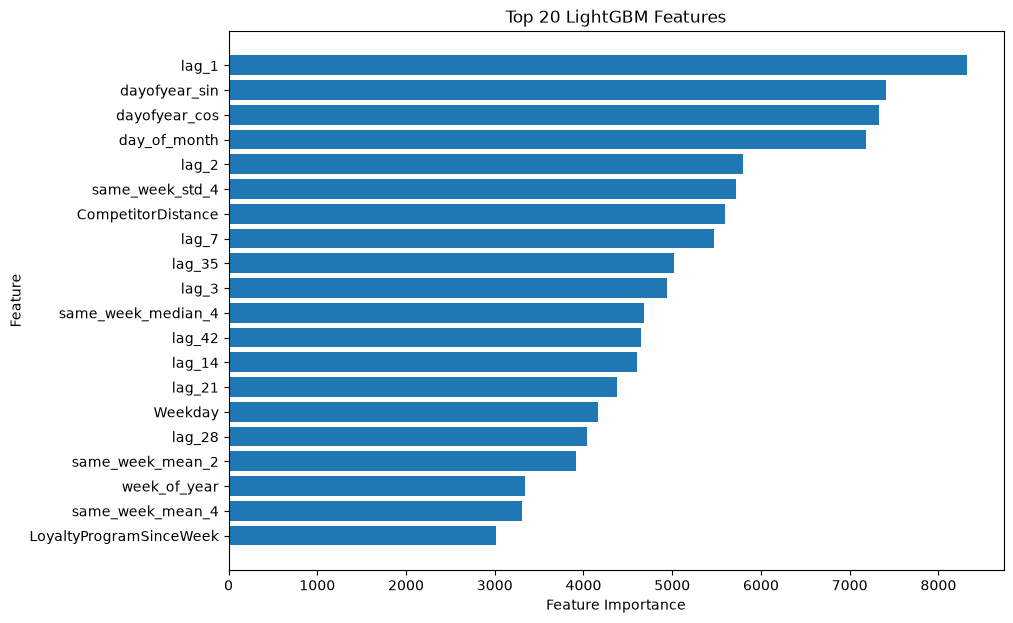

In [51]:
import matplotlib.pyplot as plt

top_n = 20

plt.figure(figsize=(10, 7))

plt.barh(
    importance_df["Feature"].head(top_n)[::-1],
    importance_df["Importance"].head(top_n)[::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 LightGBM Features")

plt.show()

In [52]:
# ============================================================
# CHECK TRAIN / VALIDATION / TEST FEATURE AVAILABILITY
# ============================================================

print("Features used by model:")
print(FEATURES)

print("\nMissing features in TEST:")

missing_test_features = [
    col for col in FEATURES
    if col not in test_model.columns
]

print(missing_test_features)

Features used by model:
['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35', 'lag_42', 'same_week_mean_2', 'same_week_mean_4', 'same_week_median_4', 'same_week_std_4', 'Weekday', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'weekday_sin', 'weekday_cos', 'dayofyear_sin', 'dayofyear_cos', 'IsOpen', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag', 'promo_open', 'holiday_open', 'HubFormat', 'AssortmentTier', 'CompetitorDistance', 'CompetitorOpenSinceMonth', 'CompetitorOpenSinceYear', 'LoyaltyProgram', 'LoyaltyProgramSinceWeek', 'LoyaltyProgramSinceYear']

Missing features in TEST:
['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'lag_35', 'lag_42', 'same_week_mean_2', 'same_week_mean_4', 'same_week_median_4', 'same_week_std_4', 'promo_open', 'holiday_open']


In [53]:
# ============================================================
# 9.1 FEATURE LIST
# ============================================================

FEATURES = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "lag_35",
    "lag_42",
    
    "same_week_mean_2",
    "same_week_mean_4",
    "same_week_median_4",
    "same_week_std_4",
    
    "Weekday",
    "month",
    "day_of_month",
    "week_of_year",
    "is_weekend",
    
    "weekday_sin",
    "weekday_cos",
    "dayofyear_sin",
    "dayofyear_cos",
    
    "IsOpen",
    "PromoActive",
    "RegionalHoliday",
    "SchoolClosureFlag",
    
    "promo_open",
    "holiday_open",
    
    "HubFormat",
    "AssortmentTier",
    "CompetitorDistance",
    "CompetitorOpenSinceMonth",
    "CompetitorOpenSinceYear",
    "LoyaltyProgram",
    "LoyaltyProgramSinceWeek",
    "LoyaltyProgramSinceYear"
]

print("Number of features:", len(FEATURES))

Number of features: 36


In [54]:
# ============================================================
# 9.2 FEATURE ENGINEERING FUNCTION
# ============================================================

def create_features(df):
    df = df.copy()

    df["Date"] = pd.to_datetime(df["Date"])

    df = df.sort_values(["HubID", "Date"]).reset_index(drop=True)

    # --------------------------------------------------------
    # TIME FEATURES
    # --------------------------------------------------------
    
    df["year"] = df["Date"].dt.year
    df["month"] = df["Date"].dt.month
    df["day_of_month"] = df["Date"].dt.day
    df["week_of_year"] = df["Date"].dt.isocalendar().week.astype(int)
    df["day_of_year"] = df["Date"].dt.dayofyear
    
    df["is_weekend"] = (df["Weekday"] >= 6).astype(int)

    # --------------------------------------------------------
    # CYCLICAL FEATURES
    # --------------------------------------------------------
    
    df["weekday_sin"] = np.sin(2 * np.pi * df["Weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["Weekday"] / 7)

    df["dayofyear_sin"] = np.sin(
        2 * np.pi * df["day_of_year"] / 365.25
    )

    df["dayofyear_cos"] = np.cos(
        2 * np.pi * df["day_of_year"] / 365.25
    )

    # --------------------------------------------------------
    # LAGS
    # --------------------------------------------------------
    
    for lag in [1, 2, 3, 7, 14, 21, 28, 35, 42]:
        df[f"lag_{lag}"] = (
            df.groupby("HubID")["OrderVolume"]
              .shift(lag)
        )

    # --------------------------------------------------------
    # SAME-WEEKDAY FEATURES
    #
    # Since weekday repeats every 7 days:
    # lag 7, 14, 21, 28 correspond to previous same weekdays.
    # --------------------------------------------------------
    
    df["same_week_mean_2"] = df[
        ["lag_7", "lag_14"]
    ].mean(axis=1)

    df["same_week_mean_4"] = df[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].mean(axis=1)

    df["same_week_median_4"] = df[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].median(axis=1)

    df["same_week_std_4"] = df[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].std(axis=1)

    # --------------------------------------------------------
    # OPERATIONAL INTERACTIONS
    # --------------------------------------------------------
    
    df["promo_open"] = df["PromoActive"] * df["IsOpen"]

    df["holiday_open"] = df["RegionalHoliday"] * df["IsOpen"]

    return df

In [55]:
# ============================================================
# 9.3 42-DAY VALIDATION SPLIT
# ============================================================

train_raw = train.copy()

train_raw["Date"] = pd.to_datetime(train_raw["Date"])

max_train_date = train_raw["Date"].max()

validation_start = max_train_date - pd.Timedelta(days=41)

print("Maximum train date:", max_train_date)
print("Validation start:", validation_start)
print("Validation end:", max_train_date)

train_part_raw = train_raw[
    train_raw["Date"] < validation_start
].copy()

valid_part_raw = train_raw[
    train_raw["Date"] >= validation_start
].copy()

print("\nTrain period:")
print(train_part_raw["Date"].min(), "to", train_part_raw["Date"].max())

print("\nValidation period:")
print(valid_part_raw["Date"].min(), "to", valid_part_raw["Date"].max())

print("\nValidation days:",
      valid_part_raw["Date"].nunique())

Maximum train date: 2015-06-19 00:00:00
Validation start: 2015-05-09 00:00:00
Validation end: 2015-06-19 00:00:00

Train period:
2013-01-01 00:00:00 to 2015-05-08 00:00:00

Validation period:
2015-05-09 00:00:00 to 2015-06-19 00:00:00

Validation days: 42


In [56]:
# ============================================================
# 9.4 MERGE METADATA
# ============================================================

train_part_raw = train_part_raw.merge(
    metadata,
    on="HubID",
    how="left",
    validate="many_to_one"
)

valid_part_raw = valid_part_raw.merge(
    metadata,
    on="HubID",
    how="left",
    validate="many_to_one"
)

print(train_part_raw.shape)
print(valid_part_raw.shape)

(923549, 18)
(46830, 18)


In [57]:
# ============================================================
# 9.5 TRAINING FEATURES
# ============================================================

train_part = create_features(train_part_raw)

print("Training feature shape:", train_part.shape)

Training feature shape: (923549, 43)


In [58]:
# ============================================================
# 9.6 REMOVE INITIAL LAG ROWS
# ============================================================

required_lags = [
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_28",
    "lag_35",
    "lag_42"
]

train_part = train_part.dropna(
    subset=required_lags
).copy()

print("Training rows after lag filtering:", len(train_part))

Training rows after lag filtering: 876719


In [59]:
# ============================================================
# 9.7 TRAIN VALIDATION MODEL
# ============================================================

validation_model = LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

X_train = train_part[FEATURES]
y_train = np.log1p(train_part["OrderVolume"])

validation_model.fit(
    X_train,
    y_train
)

print("Validation model trained.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4288
[LightGBM] [Info] Number of data points in the train set: 876719, number of used features: 36
[LightGBM] [Info] Start training from score 7.270687
Validation model trained.


In [60]:
# ============================================================
# 9.8 HISTORY FOR RECURSIVE FORECASTING
# ============================================================

history = train_part_raw[
    ["HubID", "Date", "OrderVolume"]
].copy()

history["Date"] = pd.to_datetime(history["Date"])

history = history.set_index(
    ["HubID", "Date"]
)["OrderVolume"]

print("Historical observations:", len(history))

Historical observations: 923549


In [61]:
# ============================================================
# 9.8 HISTORY FOR RECURSIVE FORECASTING
# ============================================================

history = train_part_raw[
    ["HubID", "Date", "OrderVolume"]
].copy()

history["Date"] = pd.to_datetime(history["Date"])

history = history.set_index(
    ["HubID", "Date"]
)["OrderVolume"]

print("Historical observations:", len(history))

Historical observations: 923549


In [62]:
# ============================================================
# 9.9 RECURSIVE VALIDATION
# ============================================================

validation_predictions = []

validation_dates = sorted(
    valid_part_raw["Date"].unique()
)

for i, current_date in enumerate(validation_dates, start=1):

    # --------------------------------------------------------
    # Rows for today's validation date
    # --------------------------------------------------------
    
    current_rows = valid_part_raw[
        valid_part_raw["Date"] == current_date
    ].copy()

    current_rows = current_rows.sort_values(
        "HubID"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Helper function to obtain historical target
    # --------------------------------------------------------
    
    def get_lag_values(days):
        lag_dates = current_rows["Date"] - pd.Timedelta(days=days)

        keys = list(
            zip(
                current_rows["HubID"],
                lag_dates
            )
        )

        return pd.Series(
            [history.get(key, np.nan) for key in keys],
            index=current_rows.index
        )

    # --------------------------------------------------------
    # Create lag features manually
    # --------------------------------------------------------
    
    current_rows["lag_1"] = get_lag_values(1)
    current_rows["lag_2"] = get_lag_values(2)
    current_rows["lag_3"] = get_lag_values(3)
    current_rows["lag_7"] = get_lag_values(7)
    current_rows["lag_14"] = get_lag_values(14)
    current_rows["lag_21"] = get_lag_values(21)
    current_rows["lag_28"] = get_lag_values(28)
    current_rows["lag_35"] = get_lag_values(35)
    current_rows["lag_42"] = get_lag_values(42)

    # --------------------------------------------------------
    # Same-weekday features
    # --------------------------------------------------------
    
    current_rows["same_week_mean_2"] = current_rows[
        ["lag_7", "lag_14"]
    ].mean(axis=1)

    current_rows["same_week_mean_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].mean(axis=1)

    current_rows["same_week_median_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].median(axis=1)

    current_rows["same_week_std_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].std(axis=1)

    # --------------------------------------------------------
    # Time features
    # --------------------------------------------------------
    
    current_rows["year"] = current_rows["Date"].dt.year
    current_rows["month"] = current_rows["Date"].dt.month
    current_rows["day_of_month"] = current_rows["Date"].dt.day

    current_rows["week_of_year"] = (
        current_rows["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    current_rows["day_of_year"] = (
        current_rows["Date"].dt.dayofyear
    )

    current_rows["is_weekend"] = (
        current_rows["Weekday"] >= 6
    ).astype(int)

    current_rows["weekday_sin"] = np.sin(
        2 * np.pi * current_rows["Weekday"] / 7
    )

    current_rows["weekday_cos"] = np.cos(
        2 * np.pi * current_rows["Weekday"] / 7
    )

    current_rows["dayofyear_sin"] = np.sin(
        2 * np.pi *
        current_rows["day_of_year"] / 365.25
    )

    current_rows["dayofyear_cos"] = np.cos(
        2 * np.pi *
        current_rows["day_of_year"] / 365.25
    )

    # --------------------------------------------------------
    # Interactions
    # --------------------------------------------------------
    
    current_rows["promo_open"] = (
        current_rows["PromoActive"] *
        current_rows["IsOpen"]
    )

    current_rows["holiday_open"] = (
        current_rows["RegionalHoliday"] *
        current_rows["IsOpen"]
    )

    # --------------------------------------------------------
    # Check lag availability
    # --------------------------------------------------------
    
    if current_rows[FEATURES].isnull().any().any():
        missing_counts = (
            current_rows[FEATURES]
            .isnull()
            .sum()
        )

        print(
            "Missing feature values on:",
            current_date
        )

        print(
            missing_counts[
                missing_counts > 0
            ]
        )

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------
    
    X_current = current_rows[FEATURES]

    pred_log = validation_model.predict(
        X_current
    )

    predictions = np.maximum(
        np.expm1(pred_log),
        0
    )

    # Closed hubs must have zero demand
    predictions[
        current_rows["IsOpen"].values == 0
    ] = 0

    # --------------------------------------------------------
    # Store predictions
    # --------------------------------------------------------
    
    current_rows["Prediction"] = predictions

    validation_predictions.append(
        current_rows[
            ["HubID", "Date", "Prediction"]
        ]
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Add predictions to history.
    #
    # Future validation dates will now use these predictions.
    # --------------------------------------------------------
    
    for hub, date, prediction in zip(
        current_rows["HubID"],
        current_rows["Date"],
        predictions
    ):
        history.loc[(hub, date)] = prediction

    print(
        f"Validation day {i:02d}/42 completed: "
        f"{pd.Timestamp(current_date).date()}"
    )

Missing feature values on: 2015-05-09 00:00:00
CompetitorDistance            3
CompetitorOpenSinceMonth    354
CompetitorOpenSinceYear     354
LoyaltyProgramSinceWeek     544
LoyaltyProgramSinceYear     544
dtype: int64
Validation day 01/42 completed: 2015-05-09
Missing feature values on: 2015-05-10 00:00:00
CompetitorDistance            3
CompetitorOpenSinceMonth    354
CompetitorOpenSinceYear     354
LoyaltyProgramSinceWeek     544
LoyaltyProgramSinceYear     544
dtype: int64
Validation day 02/42 completed: 2015-05-10
Missing feature values on: 2015-05-11 00:00:00
CompetitorDistance            3
CompetitorOpenSinceMonth    354
CompetitorOpenSinceYear     354
LoyaltyProgramSinceWeek     544
LoyaltyProgramSinceYear     544
dtype: int64
Validation day 03/42 completed: 2015-05-11
Missing feature values on: 2015-05-12 00:00:00
CompetitorDistance            3
CompetitorOpenSinceMonth    354
CompetitorOpenSinceYear     354
LoyaltyProgramSinceWeek     544
LoyaltyProgramSinceYear     544
dtyp

In [63]:
# ============================================================
# 9.10 LEAKAGE-SAFE RMSLE
# ============================================================

validation_predictions = pd.concat(
    validation_predictions,
    ignore_index=True
)

validation_actual = valid_part_raw[
    ["HubID", "Date", "OrderVolume"]
].copy()

validation_actual["Date"] = pd.to_datetime(
    validation_actual["Date"]
)

validation_results = validation_actual.merge(
    validation_predictions,
    on=["HubID", "Date"],
    how="inner"
)

rmsle = np.sqrt(
    np.mean(
        (
            np.log1p(validation_results["Prediction"])
            -
            np.log1p(validation_results["OrderVolume"])
        ) ** 2
    )
)

print("=" * 60)
print("LEAKAGE-SAFE VALIDATION RMSLE:", rmsle)
print("=" * 60)

print(
    "Validation rows:",
    len(validation_results)
)

LEAKAGE-SAFE VALIDATION RMSLE: 0.14559571670290752
Validation rows: 46830


In [64]:
# ============================================================
# 9.11 LAG-7 BASELINE
# ============================================================

baseline_predictions = []

baseline_history = train_part_raw[
    ["HubID", "Date", "OrderVolume"]
].copy()

baseline_history["Date"] = pd.to_datetime(
    baseline_history["Date"]
)

baseline_history = baseline_history.set_index(
    ["HubID", "Date"]
)["OrderVolume"]

for current_date in validation_dates:

    current_rows = valid_part_raw[
        valid_part_raw["Date"] == current_date
    ].copy()

    preds = []

    for hub in current_rows["HubID"]:

        lag_date = (
            pd.Timestamp(current_date)
            - pd.Timedelta(days=7)
        )

        value = baseline_history.get(
            (hub, lag_date),
            0
        )

        preds.append(value)

    current_rows["Prediction"] = np.maximum(
        preds,
        0
    )

    current_rows.loc[
        current_rows["IsOpen"] == 0,
        "Prediction"
    ] = 0

    baseline_predictions.append(
        current_rows[
            ["HubID", "Date", "Prediction"]
        ]
    )

    # Add today's predictions to history
    for hub, date, prediction in zip(
        current_rows["HubID"],
        current_rows["Date"],
        current_rows["Prediction"]
    ):
        baseline_history.loc[
            (hub, date)
        ] = prediction

baseline_predictions = pd.concat(
    baseline_predictions,
    ignore_index=True
)

baseline_results = validation_actual.merge(
    baseline_predictions,
    on=["HubID", "Date"],
    how="inner"
)

baseline_rmsle = np.sqrt(
    np.mean(
        (
            np.log1p(
                baseline_results["Prediction"]
            )
            -
            np.log1p(
                baseline_results["OrderVolume"]
            )
        ) ** 2
    )
)

print("Recursive Lag-7 RMSLE:", baseline_rmsle)
print("Recursive LightGBM RMSLE:", rmsle)

KeyboardInterrupt: 

In [ ]:
# ============================================================
# 10.1 PREPARE TEST DATA
# ============================================================

test_raw = test.copy()

test_raw["Date"] = pd.to_datetime(
    test_raw["Date"]
)

test_raw = test_raw.merge(
    metadata,
    on="HubID",
    how="left",
    validate="many_to_one"
)

test_raw = test_raw.sort_values(
    ["Date", "HubID"]
).reset_index(drop=True)

print("Test shape:", test_raw.shape)
print(
    "Test dates:",
    test_raw["Date"].min(),
    "to",
    test_raw["Date"].max()
)

print(
    "Number of test days:",
    test_raw["Date"].nunique()
)

In [ ]:
# ============================================================
# 10.2 FULL TRAINING HISTORY
# ============================================================

full_history = train[
    ["HubID", "Date", "OrderVolume"]
].copy()

full_history["Date"] = pd.to_datetime(
    full_history["Date"]
)

full_history = full_history.set_index(
    ["HubID", "Date"]
)["OrderVolume"]

print(
    "Historical observations:",
    len(full_history)
)

In [ ]:
# ============================================================
# 10.3 RECURSIVE TEST FORECAST
# ============================================================

test_predictions = []

test_dates = sorted(
    test_raw["Date"].unique()
)

for i, current_date in enumerate(
    test_dates,
    start=1
):

    current_rows = test_raw[
        test_raw["Date"] == current_date
    ].copy()

    current_rows = current_rows.sort_values(
        "HubID"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # LAGS
    # --------------------------------------------------------
    
    def get_test_lag_values(days):

        lag_dates = (
            current_rows["Date"]
            - pd.Timedelta(days=days)
        )

        keys = list(
            zip(
                current_rows["HubID"],
                lag_dates
            )
        )

        return pd.Series(
            [
                full_history.get(key, np.nan)
                for key in keys
            ],
            index=current_rows.index
        )

    current_rows["lag_1"] = get_test_lag_values(1)
    current_rows["lag_2"] = get_test_lag_values(2)
    current_rows["lag_3"] = get_test_lag_values(3)
    current_rows["lag_7"] = get_test_lag_values(7)
    current_rows["lag_14"] = get_test_lag_values(14)
    current_rows["lag_21"] = get_test_lag_values(21)
    current_rows["lag_28"] = get_test_lag_values(28)
    current_rows["lag_35"] = get_test_lag_values(35)
    current_rows["lag_42"] = get_test_lag_values(42)

    # --------------------------------------------------------
    # SAME-WEEKDAY FEATURES
    # --------------------------------------------------------
    
    current_rows["same_week_mean_2"] = current_rows[
        ["lag_7", "lag_14"]
    ].mean(axis=1)

    current_rows["same_week_mean_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].mean(axis=1)

    current_rows["same_week_median_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].median(axis=1)

    current_rows["same_week_std_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].std(axis=1)

    # --------------------------------------------------------
    # TIME FEATURES
    # --------------------------------------------------------
    
    current_rows["year"] = current_rows["Date"].dt.year
    current_rows["month"] = current_rows["Date"].dt.month
    current_rows["day_of_month"] = current_rows["Date"].dt.day

    current_rows["week_of_year"] = (
        current_rows["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    current_rows["day_of_year"] = (
        current_rows["Date"].dt.dayofyear
    )

    current_rows["is_weekend"] = (
        current_rows["Weekday"] >= 6
    ).astype(int)

    current_rows["weekday_sin"] = np.sin(
        2 * np.pi * current_rows["Weekday"] / 7
    )

    current_rows["weekday_cos"] = np.cos(
        2 * np.pi * current_rows["Weekday"] / 7
    )

    current_rows["dayofyear_sin"] = np.sin(
        2 * np.pi *
        current_rows["day_of_year"] / 365.25
    )

    current_rows["dayofyear_cos"] = np.cos(
        2 * np.pi *
        current_rows["day_of_year"] / 365.25
    )

    # --------------------------------------------------------
    # INTERACTIONS
    # --------------------------------------------------------
    
    current_rows["promo_open"] = (
        current_rows["PromoActive"] *
        current_rows["IsOpen"]
    )

    current_rows["holiday_open"] = (
        current_rows["RegionalHoliday"] *
        current_rows["IsOpen"]
    )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------
    
    X_current = current_rows[FEATURES]

    pred_log = validation_model.predict(
        X_current
    )

    predictions = np.maximum(
        np.expm1(pred_log),
        0
    )

    # Closed hub = zero orders
    predictions[
        current_rows["IsOpen"].values == 0
    ] = 0

    current_rows["Prediction"] = predictions

    test_predictions.append(
        current_rows[
            ["Id", "HubID", "Date", "Prediction"]
        ]
    )

    # --------------------------------------------------------
    # ADD PREDICTION TO HISTORY
    # --------------------------------------------------------
    
    for hub, date, prediction in zip(
        current_rows["HubID"],
        current_rows["Date"],
        predictions
    ):

        full_history.loc[
            (hub, date)
        ] = prediction

    print(
        f"Test day {i:02d}/42 completed: "
        f"{pd.Timestamp(current_date).date()}"
    )

In [ ]:
test_predictions = pd.concat(
    test_predictions,
    ignore_index=True
)

print(
    "Predictions generated:",
    len(test_predictions)
)

In [65]:
# ============================================================
# 10. FINAL MODEL - TRAIN ON ALL AVAILABLE HISTORY
# ============================================================

full_train = train.copy()

full_train["Date"] = pd.to_datetime(full_train["Date"])

# Merge metadata
full_train = full_train.merge(
    metadata,
    on="HubID",
    how="left",
    validate="many_to_one"
)

# Create features
full_train_features = create_features(full_train)

# Remove rows without enough lag history
full_train_features = full_train_features.dropna(
    subset=required_lags
).copy()

print("Final training shape:", full_train_features.shape)

# ------------------------------------------------------------
# Final LightGBM
# ------------------------------------------------------------

final_model = LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    full_train_features[FEATURES],
    np.log1p(
        full_train_features["OrderVolume"]
    )
)

print("FINAL MODEL TRAINED.")

Final training shape: (923549, 43)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058792 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4291
[LightGBM] [Info] Number of data points in the train set: 923549, number of used features: 36
[LightGBM] [Info] Start training from score 7.259603
FINAL MODEL TRAINED.


In [69]:
# ============================================================
# 11. PREPARE TEST DATA
# ============================================================

test_final = test.copy()

test_final["Date"] = pd.to_datetime(
    test_final["Date"]
)

test_final = test_final.merge(
    metadata,
    on="HubID",
    how="left",
    validate="many_to_one"
)

test_final = test_final.sort_values(
    ["Date", "HubID"]
).reset_index(drop=True)

print("Test shape:", test_final.shape)
print(
    "Test dates:",
    test_final["Date"].min(),
    "to",
    test_final["Date"].max()
)

Test shape: (46830, 17)
Test dates: 2015-06-20 00:00:00 to 2015-07-31 00:00:00


In [70]:
# ============================================================
# 12. INITIALIZE HISTORY
# ============================================================

final_history = train[
    ["HubID", "Date", "OrderVolume"]
].copy()

final_history["Date"] = pd.to_datetime(
    final_history["Date"]
)

final_history = final_history.set_index(
    ["HubID", "Date"]
)["OrderVolume"]

print(
    "Historical observations:",
    len(final_history)
)

Historical observations: 970379


In [71]:
# STEP 13 FIX — initialize final_history

final_history = (
    full_train[["HubID", "Date", "OrderVolume"]]
    .copy()
)

final_history["Date"] = pd.to_datetime(final_history["Date"])

final_history = final_history.set_index(["HubID", "Date"])["OrderVolume"].to_dict()

print("final_history initialized")
print("History entries:", len(final_history))

final_history initialized
History entries: 970379


In [75]:
final_history = (
    full_train[["HubID", "Date", "OrderVolume"]]
    .copy()
)

final_history["Date"] = pd.to_datetime(final_history["Date"])
final_history = final_history.set_index(["HubID", "Date"])

In [76]:
print(final_predictions.shape)
print(final_predictions.head())

NameError: name 'final_predictions' is not defined

In [74]:
submission = pd.DataFrame({
    "Id": final_predictions["Id"],
    "OrderVolume": final_predictions["Prediction"]
})

submission = sample[["Id"]].merge(submission, on="Id", how="left")

assert len(submission) == 46830
assert submission["OrderVolume"].notna().all()
assert (submission["OrderVolume"] >= 0).all()

submission.to_csv("submission.csv", index=False)

print("DONE")
print(submission.shape)
print(submission.head())

NameError: name 'final_predictions' is not defined

In [77]:
# FINAL SUBMISSION

# Check whether Step 13 actually produced predictions
if "final_predictions" not in globals():
    raise RuntimeError(
        "FINAL PREDICTIONS DO NOT EXIST. "
        "Step 13 recursive forecasting did not finish successfully."
    )

submission = final_predictions[["Id", "Prediction"]].copy()
submission = submission.rename(columns={"Prediction": "OrderVolume"})

# Match sample submission order
submission = sample[["Id"]].merge(
    submission,
    on="Id",
    how="left"
)

assert len(submission) == 46830
assert submission["OrderVolume"].notna().all()
assert (submission["OrderVolume"] >= 0).all()

submission.to_csv("submission.csv", index=False)

print("DONE")
print("Shape:", submission.shape)
print(submission.head())
print("File: submission.csv")

RuntimeError: FINAL PREDICTIONS DO NOT EXIST. Step 13 recursive forecasting did not finish successfully.

In [72]:
# ============================================================
# 13. FINAL RECURSIVE TEST FORECAST
# ============================================================

final_test_predictions = []

test_dates = sorted(
    test_final["Date"].unique()
)

for i, current_date in enumerate(
    test_dates,
    start=1
):

    current_rows = test_final[
        test_final["Date"] == current_date
    ].copy()

    current_rows = current_rows.sort_values(
        "HubID"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # LAG FEATURES
    # --------------------------------------------------------

    def get_final_lag_values(days):

        lag_dates = (
            current_rows["Date"]
            - pd.Timedelta(days=days)
        )

        keys = list(
            zip(
                current_rows["HubID"],
                lag_dates
            )
        )

        return pd.Series(
            [
                final_history.get(
                    key,
                    np.nan
                )
                for key in keys
            ],
            index=current_rows.index
        )

    current_rows["lag_1"] = get_final_lag_values(1)
    current_rows["lag_2"] = get_final_lag_values(2)
    current_rows["lag_3"] = get_final_lag_values(3)
    current_rows["lag_7"] = get_final_lag_values(7)
    current_rows["lag_14"] = get_final_lag_values(14)
    current_rows["lag_21"] = get_final_lag_values(21)
    current_rows["lag_28"] = get_final_lag_values(28)
    current_rows["lag_35"] = get_final_lag_values(35)
    current_rows["lag_42"] = get_final_lag_values(42)

    # --------------------------------------------------------
    # SAME-WEEKDAY FEATURES
    # --------------------------------------------------------

    current_rows["same_week_mean_2"] = current_rows[
        ["lag_7", "lag_14"]
    ].mean(axis=1)

    current_rows["same_week_mean_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].mean(axis=1)

    current_rows["same_week_median_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].median(axis=1)

    current_rows["same_week_std_4"] = current_rows[
        ["lag_7", "lag_14", "lag_21", "lag_28"]
    ].std(axis=1)

    # --------------------------------------------------------
    # TIME FEATURES
    # --------------------------------------------------------

    current_rows["year"] = current_rows["Date"].dt.year
    current_rows["month"] = current_rows["Date"].dt.month
    current_rows["day_of_month"] = current_rows["Date"].dt.day

    current_rows["week_of_year"] = (
        current_rows["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    current_rows["day_of_year"] = (
        current_rows["Date"].dt.dayofyear
    )

    current_rows["is_weekend"] = (
        current_rows["Weekday"] >= 6
    ).astype(int)

    current_rows["weekday_sin"] = np.sin(
        2 * np.pi * current_rows["Weekday"] / 7
    )

    current_rows["weekday_cos"] = np.cos(
        2 * np.pi * current_rows["Weekday"] / 7
    )

    current_rows["dayofyear_sin"] = np.sin(
        2 * np.pi *
        current_rows["day_of_year"] / 365.25
    )

    current_rows["dayofyear_cos"] = np.cos(
        2 * np.pi *
        current_rows["day_of_year"] / 365.25
    )

    # --------------------------------------------------------
    # INTERACTIONS
    # --------------------------------------------------------

    current_rows["promo_open"] = (
        current_rows["PromoActive"]
        * current_rows["IsOpen"]
    )

    current_rows["holiday_open"] = (
        current_rows["RegionalHoliday"]
        * current_rows["IsOpen"]
    )

    # --------------------------------------------------------
    # CHECK FEATURES
    # --------------------------------------------------------

    missing_features = current_rows[
        FEATURES
    ].isnull().sum()

    if missing_features.sum() > 0:

        print(
            "WARNING - Missing features on:",
            current_date
        )

        print(
            missing_features[
                missing_features > 0
            ]
        )

    # --------------------------------------------------------
    # PREDICT
    # --------------------------------------------------------

    X_current = current_rows[FEATURES]

    pred_log = final_model.predict(
        X_current
    )

    predictions = np.maximum(
        np.expm1(pred_log),
        0
    )

    # Closed hubs have zero orders
    predictions[
        current_rows["IsOpen"].values == 0
    ] = 0

    current_rows["Prediction"] = predictions

    # --------------------------------------------------------
    # SAVE PREDICTIONS
    # --------------------------------------------------------

    final_test_predictions.append(
        current_rows[
            [
                "Id",
                "HubID",
                "Date",
                "Prediction"
            ]
        ]
    )

    # --------------------------------------------------------
    # ADD PREDICTIONS TO HISTORY
    # --------------------------------------------------------

    for hub, date, prediction in zip(
        current_rows["HubID"],
        current_rows["Date"],
        predictions
    ):

        final_history.loc[
            (hub, date)
        ] = prediction

    print(
        f"Test day {i:02d}/42 completed: "
        f"{pd.Timestamp(current_date).date()}"
    )

WARNING - Missing features on: 2015-06-20 00:00:00
CompetitorDistance            3
CompetitorOpenSinceMonth    354
CompetitorOpenSinceYear     354
LoyaltyProgramSinceWeek     544
LoyaltyProgramSinceYear     544
dtype: int64


AttributeError: 'dict' object has no attribute 'loc'

In [ ]:
# ============================================================
# 14. COMBINE FINAL PREDICTIONS
# ============================================================

final_test_predictions = pd.concat(
    final_test_predictions,
    ignore_index=True
)

print(
    "Total predictions:",
    len(final_test_predictions)
)

print(
    final_test_predictions.head()
)

In [78]:
# ============================================================
# STEP 13 — FINAL RECURSIVE TEST FORECAST
# ============================================================

print("Starting final recursive forecast...")

# ------------------------------------------------------------
# 1. Prepare test data
# ------------------------------------------------------------
test_final = orders_test.copy()

test_final["Date"] = pd.to_datetime(test_final["Date"])

test_final = test_final.merge(
    metadata,
    on="HubID",
    how="left"
)

test_final = test_final.sort_values(
    ["Date", "HubID"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 2. Create history from ALL training data
# ------------------------------------------------------------
final_history = (
    full_train[["HubID", "Date", "OrderVolume"]]
    .copy()
)

final_history["Date"] = pd.to_datetime(final_history["Date"])

final_history = final_history.set_index(
    ["HubID", "Date"]
)

# ------------------------------------------------------------
# 3. Forecast day by day
# ------------------------------------------------------------
all_predictions = []

forecast_dates = sorted(test_final["Date"].unique())

for day_number, current_date in enumerate(forecast_dates, 1):

    print(
        f"Forecasting {day_number}/{len(forecast_dates)}: "
        f"{pd.Timestamp(current_date).date()}"
    )

    current_rows = test_final[
        test_final["Date"] == current_date
    ].copy()

    current_rows = current_rows.sort_values(
        "HubID"
    ).reset_index(drop=True)

    # --------------------------------------------------------
    # Generate lag features
    # --------------------------------------------------------
    for lag in [1, 2, 3, 7, 14, 21, 28, 35, 42]:

        lag_dates = (
            current_rows["Date"]
            - pd.to_timedelta(lag, unit="D")
        )

        lag_values = []

        for hub, lag_date in zip(
            current_rows["HubID"],
            lag_dates
        ):

            try:
                value = final_history.loc[
                    (hub, lag_date),
                    "OrderVolume"
                ]
            except KeyError:
                value = np.nan

            lag_values.append(value)

        current_rows[f"lag_{lag}"] = lag_values

    # --------------------------------------------------------
    # Same-week statistics
    # --------------------------------------------------------
    current_rows["same_week_mean_2"] = (
        current_rows[["lag_7", "lag_14"]]
        .mean(axis=1)
    )

    current_rows["same_week_mean_4"] = (
        current_rows[
            ["lag_7", "lag_14", "lag_21", "lag_28"]
        ].mean(axis=1)
    )

    current_rows["same_week_median_4"] = (
        current_rows[
            ["lag_7", "lag_14", "lag_21", "lag_28"]
        ].median(axis=1)
    )

    current_rows["same_week_std_4"] = (
        current_rows[
            ["lag_7", "lag_14", "lag_21", "lag_28"]
        ].std(axis=1)
    )

    # --------------------------------------------------------
    # Calendar features
    # --------------------------------------------------------
    current_rows["year"] = (
        current_rows["Date"].dt.year
    )

    current_rows["month"] = (
        current_rows["Date"].dt.month
    )

    current_rows["day_of_month"] = (
        current_rows["Date"].dt.day
    )

    current_rows["week_of_year"] = (
        current_rows["Date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    current_rows["day_of_year"] = (
        current_rows["Date"].dt.dayofyear
    )

    current_rows["is_weekend"] = (
        current_rows["Weekday"] >= 6
    ).astype(int)

    # --------------------------------------------------------
    # Cyclic features
    # --------------------------------------------------------
    current_rows["weekday_sin"] = np.sin(
        2 * np.pi * current_rows["Weekday"] / 7
    )

    current_rows["weekday_cos"] = np.cos(
        2 * np.pi * current_rows["Weekday"] / 7
    )

    current_rows["dayofyear_sin"] = np.sin(
        2 * np.pi *
        current_rows["day_of_year"] /
        365.25
    )

    current_rows["dayofyear_cos"] = np.cos(
        2 * np.pi *
        current_rows["day_of_year"] /
        365.25
    )

    # --------------------------------------------------------
    # Interaction features
    # --------------------------------------------------------
    current_rows["promo_open"] = (
        current_rows["PromoActive"] *
        current_rows["IsOpen"]
    )

    current_rows["holiday_open"] = (
        current_rows["RegionalHoliday"] *
        current_rows["IsOpen"]
    )

    # --------------------------------------------------------
    # Predict
    # --------------------------------------------------------
    X_current = current_rows[FEATURES]

    log_predictions = final_model.predict(X_current)

    predictions = np.expm1(log_predictions)

    predictions = np.clip(
        predictions,
        0,
        None
    )

    # Closed hubs = zero demand
    predictions[
        current_rows["IsOpen"].values == 0
    ] = 0

    # --------------------------------------------------------
    # Store predictions
    # --------------------------------------------------------
    current_rows["Prediction"] = predictions

    all_predictions.append(
        current_rows[
            ["Id", "HubID", "Date", "Prediction"]
        ].copy()
    )

    # --------------------------------------------------------
    # IMPORTANT:
    # Add today's predictions to history so that
    # tomorrow's lag_1, lag_2, etc. can use them.
    # --------------------------------------------------------
    for hub, date, prediction in zip(
        current_rows["HubID"],
        current_rows["Date"],
        predictions
    ):

        final_history.loc[
            (hub, date),
            "OrderVolume"
        ] = prediction


# ------------------------------------------------------------
# 4. Combine all forecast days
# ------------------------------------------------------------
final_predictions = pd.concat(
    all_predictions,
    ignore_index=True
)

print()
print("============================================")
print("FINAL FORECAST COMPLETE")
print("============================================")
print("Prediction rows:", len(final_predictions))
print(final_predictions.head())

Starting final recursive forecast...


NameError: name 'orders_test' is not defined

In [79]:
import pandas as pd
import numpy as np

orders_train = pd.read_csv("orders_train.csv")
orders_test = pd.read_csv("orders_test.csv")
metadata = pd.read_csv("metadata.csv")

orders_train["Date"] = pd.to_datetime(orders_train["Date"])
orders_test["Date"] = pd.to_datetime(orders_test["Date"])

full_train = orders_train.copy()

print("Loaded:")
print("Train:", orders_train.shape)
print("Test:", orders_test.shape)
print("Metadata:", metadata.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'metadata.csv'